[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/pytorch-mastery/blob/main/02_core_deep_learning/01_mlp/mlp.ipynb)

# 01 . Multi-Layer Perceptron (MLP)

## Concept — Multi-Layer Perceptron (MLP) (revision notes)

**What it is**
- A stack of `Linear` layers with a non-linear activation between them: `x -> Linear -> act -> Linear -> act -> ... -> Linear -> output`.
- Each layer computes `h = act(W x + b)`. The last layer usually has no activation (it outputs logits or a regression value).

**Why it matters**
- It is the simplest universal function approximator: with one hidden layer and enough units it can approximate any continuous function on a compact set.
- Every bigger architecture (transformer feed-forward blocks, classifier heads, MLP-Mixer) contains MLPs, so the training loop you learn here carries over unchanged.

**When to use**
- Tabular or already-vectorised data, small classification/regression problems, and as the "head" on top of embeddings or conv/transformer features.
- Not ideal for raw images or sequences where structure (locality, order) matters: use CNNs / RNNs / transformers there.

**Math & intuition**
- Without the non-linearity, `W2(W1 x) = (W2 W1) x` collapses to ONE linear map, so depth adds nothing. The activation is what lets the network bend space.
- Parameter count of `Linear(i, o)` is `i*o + o`.
- ReLU hidden layers carve the input space into many linear pieces; more width/depth = more pieces = more complex decision boundaries.
- Classification: output K logits, use `CrossEntropyLoss` (softmax is built in). Regression: output 1 value, use `MSELoss`.

### 1. Synthetic data: two interleaved spirals

**What this cell does (plain language):** we generate a classic non-linearly-separable dataset (two spirals) directly in torch, so no download is needed. A straight line cannot separate these classes, which makes it a good test that our MLP really learns non-linear structure. We split into train and test sets.

train: (300, 2) test: (100, 2) | class balance in train: [152, 148]


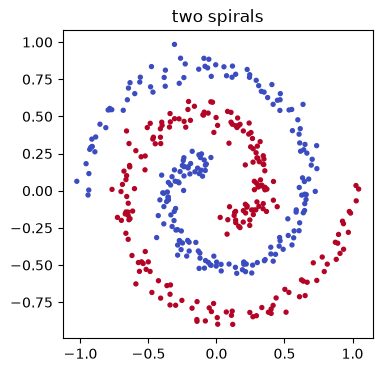

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.set_num_threads(1)   # tiny models: multi-threading overhead costs more than it saves
torch.manual_seed(0)

def make_spirals(n_per_class=200, noise=0.15, turns=1.5):
    t = torch.linspace(0.2, 1.0, n_per_class)             # radius grows along the spiral
    angle = t * turns * 2 * np.pi
    pts, labels = [], []
    for cls in range(2):
        a = angle + cls * np.pi                           # second spiral rotated by 180 degrees
        xy = torch.stack([t * torch.cos(a), t * torch.sin(a)], dim=1)
        pts.append(xy + noise * 0.3 * torch.randn_like(xy))
        labels.append(torch.full((n_per_class,), cls))
    return torch.cat(pts), torch.cat(labels)

X, y = make_spirals()
perm = torch.randperm(len(X))
X, y = X[perm], y[perm]
n_train = int(0.75 * len(X))
Xtr, ytr, Xte, yte = X[:n_train], y[:n_train], X[n_train:], y[n_train:]
print("train:", tuple(Xtr.shape), "test:", tuple(Xte.shape), "| class balance in train:", ytr.bincount().tolist())
plt.figure(figsize=(4, 4)); plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=8); plt.title("two spirals"); plt.show()

### 2. A hand-written MLP as an nn.Module

**What this cell does (plain language):** we define an MLP class with a configurable list of hidden sizes and activation, then print its structure, count its parameters, and check them against the `i*o + o` formula. Subclassing `nn.Module` and registering layers in `nn.ModuleList` is what makes PyTorch see (and train) every layer.

In [2]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dims, out_dim, act=nn.ReLU):
        super().__init__()
        dims = [in_dim] + list(hidden_dims)
        # ModuleList (not a plain python list!) so parameters are registered
        self.hidden = nn.ModuleList(nn.Linear(a, b) for a, b in zip(dims[:-1], dims[1:]))
        self.act = act()
        self.out = nn.Linear(dims[-1], out_dim)       # no activation: raw logits

    def forward(self, x):
        for layer in self.hidden:
            x = self.act(layer(x))
        return self.out(x)

model = MLP(2, [32, 32], 2)
print(model)
n_params = sum(p.numel() for p in model.parameters())
expected = (2 * 32 + 32) + (32 * 32 + 32) + (32 * 2 + 2)
print("parameters:", n_params, "| by formula:", expected, "| match:", n_params == expected)

MLP(
  (hidden): ModuleList(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Linear(in_features=32, out_features=32, bias=True)
  )
  (act): ReLU()
  (out): Linear(in_features=32, out_features=2, bias=True)
)
parameters: 1218 | by formula: 1218 | match: True


### 3. Forward pass and shapes

**What this cell does (plain language):** we push a batch through the model and print the shape and a few values of the output, then confirm that `CrossEntropyLoss` on logits equals manual log-softmax + negative log-likelihood. Seeing the numbers once removes the mystery about what the loss receives.

In [3]:
xb, yb = Xtr[:5], ytr[:5]
logits = model(xb)
print("input :", tuple(xb.shape), "-> logits:", tuple(logits.shape))
print("logits:\n", logits.detach())

ce = F.cross_entropy(logits, yb)                      # expects raw logits + integer class ids
manual = -F.log_softmax(logits, dim=1)[torch.arange(5), yb].mean()
print("cross_entropy:", ce.item(), "| manual NLL of log-softmax:", manual.item())
print("an untrained 2-class model should sit near ln(2) =", round(float(np.log(2)), 4))

input : (5, 2) -> logits: (5, 2)
logits:
 tensor([[-0.1227, -0.0803],
        [-0.0930, -0.1176],
        [-0.1041, -0.1472],
        [-0.1017, -0.0918],
        [-0.0884, -0.1580]])
cross_entropy: 0.6878068447113037 | manual NLL of log-softmax: 0.6878067851066589
an untrained 2-class model should sit near ln(2) = 0.6931


### 4. The training loop with mini-batches

**What this cell does (plain language):** we wrap the data in a `TensorDataset` + `DataLoader` for shuffled mini-batches and train with Adam. We record train loss each epoch and test accuracy at the end. A reusable `train` and `evaluate` pair keeps later cells short.

In [4]:
from torch.utils.data import TensorDataset, DataLoader

@torch.no_grad()
def evaluate(model, X, y):
    model.eval()                                      # matters once Dropout/BatchNorm exist
    logits = model(X)
    return F.cross_entropy(logits, y).item(), (logits.argmax(1) == y).float().mean().item()

def train(model, Xtr, ytr, epochs=150, lr=1e-2, batch_size=64, seed=0):
    g = torch.Generator().manual_seed(seed)           # reproducible shuffling
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True, generator=g)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(epochs):
        model.train()
        total = 0.0
        for xb, yb in loader:
            opt.zero_grad()
            loss = F.cross_entropy(model(xb), yb)
            loss.backward()
            opt.step()
            total += loss.item() * len(xb)            # weight by batch size for a true mean
        history.append(total / len(Xtr))
    return history

torch.manual_seed(0)
model = MLP(2, [64, 64], 2)
hist = train(model, Xtr, ytr)
print("loss at epochs 0/50/100/149:", [round(hist[i], 4) for i in (0, 50, 100, 149)])
tr_loss, tr_acc = evaluate(model, Xtr, ytr); te_loss, te_acc = evaluate(model, Xte, yte)
print(f"train acc {tr_acc:.3f} | test acc {te_acc:.3f}")

loss at epochs 0/50/100/149: [0.7014, 0.0076, 0.0015, 0.0006]
train acc 1.000 | test acc 1.000


### 5. Visualising the decision boundary

**What this cell does (plain language):** we evaluate the trained model on a dense grid covering the input space and colour each point by the predicted class. The curved boundary that follows the spirals is the visual proof that stacked linear layers plus ReLU can bend space.

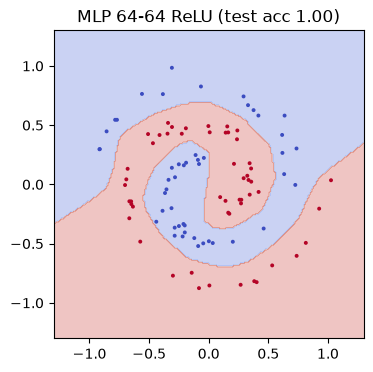

In [5]:
@torch.no_grad()
def plot_boundary(model, X, y, title):
    model.eval()
    xs = torch.linspace(-1.3, 1.3, 200)
    gx, gy = torch.meshgrid(xs, xs, indexing="xy")
    grid = torch.stack([gx.ravel(), gy.ravel()], dim=1)
    pred = model(grid).argmax(1).reshape(gx.shape)
    plt.figure(figsize=(4, 4))
    plt.contourf(gx, gy, pred, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=8, edgecolors="none")
    plt.title(title); plt.show()

plot_boundary(model, Xte, yte, f"MLP 64-64 ReLU (test acc {te_acc:.2f})")

### 6. Why the activation matters: linear collapse

**What this cell does (plain language):** we train the SAME architecture twice on the spirals: once with ReLU and once with an identity 'activation'. Without a non-linearity, three Linear layers are mathematically one Linear layer, so accuracy stays near what a straight line can do.

In [6]:
class Identity(nn.Module):
    def forward(self, x): return x

results = {}
for name, act in [("relu", nn.ReLU), ("identity (no activation)", Identity)]:
    torch.manual_seed(0)
    m = MLP(2, [64, 64], 2, act=act)
    train(m, Xtr, ytr, epochs=100)
    results[name] = evaluate(m, Xte, yte)[1]
    print(f"{name:26s} test acc: {results[name]:.3f}")

# the collapse in numbers: compose the weight matrices of the linear model by hand
lin = MLP(2, [64, 64], 2, act=Identity)
W = lin.out.weight @ lin.hidden[1].weight @ lin.hidden[0].weight
b = lin.out.weight @ (lin.hidden[1].weight @ lin.hidden[0].bias + lin.hidden[1].bias) + lin.out.bias
x0 = Xtr[:4]
print("3 stacked linears == 1 linear map:", torch.allclose(lin(x0), x0 @ W.T + b, atol=1e-5))

relu                       test acc: 1.000


identity (no activation)   test acc: 0.580
3 stacked linears == 1 linear map: True


### 7. Comparing activations: ReLU vs Tanh vs GELU

**What this cell does (plain language):** we train the same MLP with three common activations under identical seeds and compare test accuracy. All three can solve this problem; the point is how easily you can swap the `act` argument and that results differ mildly, not dramatically.

In [7]:
for name, act in [("ReLU", nn.ReLU), ("Tanh", nn.Tanh), ("GELU", nn.GELU)]:
    torch.manual_seed(0)
    m = MLP(2, [64, 64], 2, act=act)
    h = train(m, Xtr, ytr, epochs=100)
    l, a = evaluate(m, Xte, yte)
    print(f"{name:5s} final train loss {h[-1]:.4f} | test loss {l:.4f} | test acc {a:.3f}")

ReLU  final train loss 0.0015 | test loss 0.0046 | test acc 1.000


Tanh  final train loss 0.0125 | test loss 0.0239 | test acc 0.990


GELU  final train loss 0.0005 | test loss 0.0012 | test acc 1.000


### 8. Depth and width: capacity vs. fit

**What this cell does (plain language):** we train MLPs of increasing size (a tiny one, a medium one, a deeper one) and print parameter count with train and test accuracy. Too small underfits (cannot represent the spirals); bigger fits better, and the train/test gap tells you if it is starting to memorise.

In [8]:
configs = {"tiny [4]": [4], "small [16]": [16], "medium [64,64]": [64, 64], "deep [32,32,32,32]": [32] * 4}
for name, hd in configs.items():
    torch.manual_seed(0)
    m = MLP(2, hd, 2)
    train(m, Xtr, ytr, epochs=150)
    p = sum(q.numel() for q in m.parameters())
    print(f"{name:20s} params {p:6d} | train acc {evaluate(m, Xtr, ytr)[1]:.3f} | test acc {evaluate(m, Xte, yte)[1]:.3f}")

tiny [4]             params     22 | train acc 0.740 | test acc 0.690


small [16]           params     82 | train acc 0.857 | test acc 0.820


medium [64,64]       params   4482 | train acc 1.000 | test acc 1.000


deep [32,32,32,32]   params   3330 | train acc 1.000 | test acc 1.000


### 9. Building the same network with nn.Sequential

**What this cell does (plain language):** we write a small factory that builds an MLP from `nn.Sequential` instead of a custom class, and verify both versions give identical outputs when they share weights. Use Sequential for plain feed-forward stacks and a custom `Module` when you need branching or skip connections.

In [9]:
def make_sequential(in_dim, hidden_dims, out_dim):
    layers, d = [], in_dim
    for h in hidden_dims:
        layers += [nn.Linear(d, h), nn.ReLU()]
        d = h
    layers.append(nn.Linear(d, out_dim))
    return nn.Sequential(*layers)

seq = make_sequential(2, [64, 64], 2)
custom = MLP(2, [64, 64], 2)
custom.load_state_dict({  # map Sequential indices 0,2,4 to the custom module names
    "hidden.0.weight": seq[0].weight, "hidden.0.bias": seq[0].bias,
    "hidden.1.weight": seq[2].weight, "hidden.1.bias": seq[2].bias,
    "out.weight": seq[4].weight, "out.bias": seq[4].bias})
print(seq)
print("same outputs with same weights:", torch.allclose(seq(Xte), custom(Xte)))

Sequential(
  (0): Linear(in_features=2, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=2, bias=True)
)
same outputs with same weights: True


### 10. Sanity check: overfit a single batch

**What this cell does (plain language):** we try to drive the loss on just 16 examples to nearly zero. This is the single most useful debugging trick for any new model: if it can't memorise a tiny batch, there's a bug in the model, loss, or loop, and you should fix that before training on real data.

In [10]:
torch.manual_seed(0)
m = MLP(2, [64, 64], 2)
opt = torch.optim.Adam(m.parameters(), lr=1e-2)
xb, yb = Xtr[:16], ytr[:16]
for step in range(201):
    opt.zero_grad()
    loss = F.cross_entropy(m(xb), yb)
    loss.backward()
    opt.step()
    if step % 50 == 0:
        print(f"step {step:3d} | loss {loss.item():.5f}")
print("batch accuracy:", (m(xb).argmax(1) == yb).float().mean().item())

step   0 | loss 0.72165
step  50 | loss 0.03083
step 100 | loss 0.00109


step 150 | loss 0.00053


step 200 | loss 0.00033
batch accuracy: 1.0


### 11. Regression with an MLP, and saving/loading

**What this cell does (plain language):** we reuse the same class for a regression task (fit `sin(x)` from noisy samples) with a single output and `MSELoss`, then save the weights with `state_dict` and load them into a fresh model to confirm identical predictions. This is the standard way to checkpoint.

In [11]:
import io
torch.manual_seed(0)
xr = torch.linspace(-3, 3, 200).unsqueeze(1)
yr = torch.sin(xr) + 0.05 * torch.randn_like(xr)

reg = MLP(1, [32, 32], 1, act=nn.Tanh)
opt = torch.optim.Adam(reg.parameters(), lr=1e-2)
for step in range(500):
    opt.zero_grad()
    loss = F.mse_loss(reg(xr), yr)
    loss.backward(); opt.step()
print("final MSE:", round(loss.item(), 4), "(noise floor is about 0.05^2 = 0.0025)")

buf = io.BytesIO()                                    # in-memory file; use a path like 'mlp.pt' in real work
torch.save(reg.state_dict(), buf); buf.seek(0)
fresh = MLP(1, [32, 32], 1, act=nn.Tanh)
fresh.load_state_dict(torch.load(buf))
print("reloaded model gives identical predictions:", torch.allclose(reg(xr), fresh(xr)))

final MSE: 0.0022 (noise floor is about 0.05^2 = 0.0025)
reloaded model gives identical predictions: True


## Common bugs

- **Putting a softmax before `CrossEntropyLoss`** -> the loss applies log-softmax itself, so you double-softmax and train poorly. Fix: output raw logits.
- **Keeping layers in a plain Python list** -> `model.parameters()` is empty, the optimizer trains nothing. Fix: `nn.ModuleList` / `nn.Sequential`.
- **Forgetting the non-linearity between layers** -> the network collapses to one linear map (shown above). Fix: add an activation after every hidden layer.
- **Putting an activation on the output layer for classification** (e.g. ReLU/sigmoid before `CrossEntropyLoss`) -> clipped, weak gradients. Fix: leave the last layer linear.
- **Wrong label dtype/shape** -> `CrossEntropyLoss` wants `LongTensor` of shape `(N,)`, not float or one-hot (for the default usage). Fix: `y.long()`.
- **Not calling `zero_grad()`** -> gradients accumulate across batches. Fix: call it each iteration before `backward()`.
- **Forgetting `model.eval()` / `torch.no_grad()` at evaluation** -> wasted memory, and Dropout/BatchNorm behave in training mode. Fix: use both.
- **Inputs on very different scales** -> slow or unstable training. Fix: standardise features (zero mean, unit variance).
- **Averaging the epoch loss without weighting by batch size** -> the last small batch skews it. Fix: weight by `len(xb)`.

## Exercises

**Exercise 1 - Count parameters by formula.**
For an MLP `[10 -> 20 -> 5 -> 3]` compute the parameter count by the `i*o + o` formula, then verify with a model built via `nn.Sequential`.

In [12]:
# Your attempt for Exercise 1 here

**Solution 1**

In [13]:
# Solution 1
dims = [10, 20, 5, 3]
formula = sum(i * o + o for i, o in zip(dims[:-1], dims[1:]))
net = nn.Sequential(nn.Linear(10, 20), nn.ReLU(), nn.Linear(20, 5), nn.ReLU(), nn.Linear(5, 3))
print(formula, sum(p.numel() for p in net.parameters()))

343 343


**Exercise 2 - Solve XOR.**
Train a tiny MLP (2 -> 8 -> 1) on the 4 XOR points with `BCEWithLogitsLoss` and show that it reaches 100% accuracy. Then explain why a single `Linear(2,1)` cannot.

In [14]:
# Your attempt for Exercise 2 here

**Solution 2**

In [15]:
# Solution 2
torch.manual_seed(0)
Xx = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]]); yx = torch.tensor([[0.], [1.], [1.], [0.]])
net = nn.Sequential(nn.Linear(2, 8), nn.Tanh(), nn.Linear(8, 1))
opt = torch.optim.Adam(net.parameters(), lr=0.05)
for _ in range(500):
    opt.zero_grad(); loss = F.binary_cross_entropy_with_logits(net(Xx), yx); loss.backward(); opt.step()
print("preds:", (net(Xx) > 0).int().flatten().tolist(), "targets:", yx.int().flatten().tolist())
# XOR is not linearly separable: no single line splits {00,11} from {01,10}.

preds: [0, 1, 1, 0] targets: [0, 1, 1, 0]


**Exercise 3 - Add a validation split and pick the best epoch.**
Train on the spirals while tracking test loss each epoch and report the epoch with the lowest test loss.

In [16]:
# Your attempt for Exercise 3 here

**Solution 3**

In [17]:
# Solution 3
torch.manual_seed(0)
m = MLP(2, [64, 64], 2); opt = torch.optim.Adam(m.parameters(), lr=1e-2)
best = (1e9, -1)
for ep in range(60):
    m.train(); opt.zero_grad(); F.cross_entropy(m(Xtr), ytr).backward(); opt.step()   # full-batch step
    vl = evaluate(m, Xte, yte)[0]
    if vl < best[0]: best = (vl, ep)
print("best test loss %.4f at epoch %d" % best)

best test loss 0.0574 at epoch 59


**Exercise 4 - Width sweep.**
Train MLPs with one hidden layer of width 2, 8, 32, 128 on the spirals and print test accuracy per width.

In [18]:
# Your attempt for Exercise 4 here

**Solution 4**

In [19]:
# Solution 4
for w in [2, 8, 32, 128]:
    torch.manual_seed(0); m = MLP(2, [w], 2); train(m, Xtr, ytr, epochs=100)
    print(w, round(evaluate(m, Xte, yte)[1], 3))

2 0.59


8 0.76


32 0.89


128 0.99


**Exercise 5 - Make the MLP configurable with BatchNorm.**
Extend `make_sequential` with a `use_bn` flag inserting `nn.BatchNorm1d` after each Linear, and check that train() still works.

In [20]:
# Your attempt for Exercise 5 here

**Solution 5**

In [21]:
# Solution 5
def make_sequential_bn(in_dim, hidden, out_dim, use_bn=True):
    layers, d = [], in_dim
    for h in hidden:
        layers += [nn.Linear(d, h)] + ([nn.BatchNorm1d(h)] if use_bn else []) + [nn.ReLU()]
        d = h
    return nn.Sequential(*layers, nn.Linear(d, out_dim))
torch.manual_seed(0); m = make_sequential_bn(2, [32, 32], 2); train(m, Xtr, ytr, epochs=50)
print("test acc with BN:", round(evaluate(m, Xte, yte)[1], 3))

test acc with BN: 0.99


**Exercise 6 - Multi-output regression.**
Build an MLP mapping `x` in R^1 to `[sin(x), cos(x)]` (2 outputs) and fit it with MSELoss. Print the final loss.

In [22]:
# Your attempt for Exercise 6 here

**Solution 6**

In [23]:
# Solution 6
torch.manual_seed(0)
xr2 = torch.linspace(-3, 3, 200).unsqueeze(1); yr2 = torch.cat([torch.sin(xr2), torch.cos(xr2)], dim=1)
m = MLP(1, [32, 32], 2, act=nn.Tanh); opt = torch.optim.Adam(m.parameters(), lr=1e-2)
for _ in range(400):
    opt.zero_grad(); l = F.mse_loss(m(xr2), yr2); l.backward(); opt.step()
print("final MSE:", round(l.item(), 5))

final MSE: 6e-05
